In [1]:
%matplotlib widget
%reload_ext autoreload
%autoreload 2

import numpy as np
import json, os, math, glob
import importlib
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit
from IPython.display import clear_output, display

from alvra_tools.utils import *
from alvra_tools.channels import *
from alvra_tools.analysis_apo import *

import warnings
warnings.filterwarnings('ignore')

In [2]:
pgroup = 'p22591'
run = 22

channel_list = [channel_diode_1, channel_diode_2]
norm = channel_Izero110
quantile = 0.6

data, rbk, meta = load_step_scan(pgroup, run, channel_list, quantile, norm=norm)
Int1, errInt1_low, errInt1_high = unwrap_data(data, 0)
Int2, errInt2_low, errInt2_high = unwrap_data(data, 1)

100%|██████████| 41/41 [00:01<00:00, 40.33it/s]

Loaded 41 steps
Loaded 41 steps


## Plot 1 diode

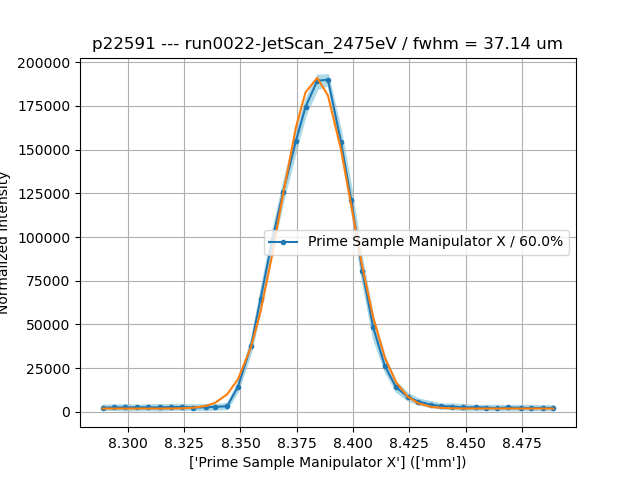

Position t0 = 8.3836 mm
Width = 37.14 um


In [3]:
Int2plot = Int1
errIntL = errInt1_low
errIntH = errInt1_high


# gaussian ---------------> [x0, amplitude, width, offset]
fit = Fit(gaussian, estimate_gaussian_parameters)
fit.estimate(rbk, Int2plot)            # this sets some internal params 

#fit.p0 = better_p0(fit.p0, 0, 210.42) # overwrite some values (index) if needed: 

fit.fit(rbk, Int2plot)                  # calculate the fit
ke_fit = fit.eval(rbk)            # evaluate the curve for plotting

centerpos_mm = fit.popt[0]
width = fit.popt[2]*2.355

plt.figure()
plt.title(meta['title'] + ' / fwhm = {:.2f} um'.format(width*1000))

plt.plot(rbk, Int2plot, label=meta['xlabel'] +' / {}%'.format(quantile*100),marker='.')
plt.fill_between(rbk, errInt1_low, errInt1_high, color='lightblue')
plt.plot(rbk, ke_fit)

plt.ylabel('Normalized intensity')
plt.xlabel('{} ({})'.format(meta['xlabel'], meta['units']))
plt.legend(loc="best")
plt.grid()
plt.show()

print("Position t0 = {:.4f} mm".format(centerpos_mm))
print("Width = {:.2f} um".format(width*1000))

## Plot 2 diode

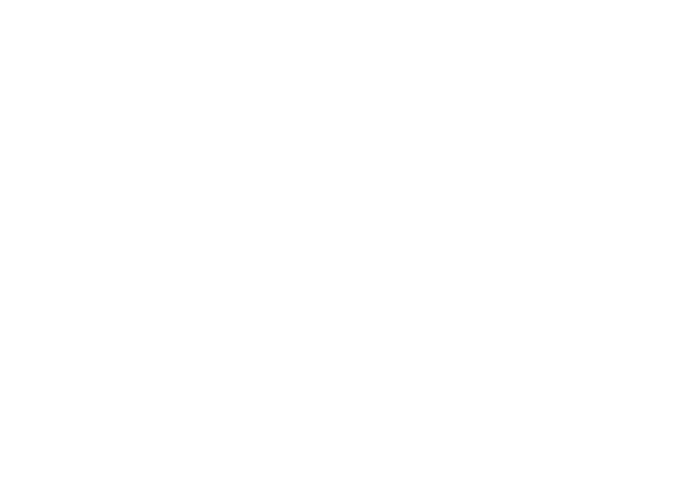

In [4]:
# gaussian ---------------> [x0, amplitude, width, offset]

fit = Fit(gaussian, estimate_gaussian_parameters)
fit.estimate(rbk, Int1)            # this sets some internal params 
#fit.p0 = better_p0(fit.p0, 0, 210.42) # overwrite some values (index) if needed: 
fit.fit(rbk, Int1)                  # calculate the fit
ke_fit1 = fit.eval(rbk)            # evaluate the curve for plotting
centerpos_mm1 = fit.popt[0]
width1 = fit.popt[2]*2.355

fit = Fit(gaussian, estimate_gaussian_parameters)
fit.estimate(rbk, Int2)            # this sets some internal params 
#fit.p0 = better_p0(fit.p0, 0, 210.42) # overwrite some values (index) if needed: 
fit.fit(rbk, Int2)                  # calculate the fit
ke_fit2 = fit.eval(rbk)            # evaluate the curve for plotting
centerpos_mm2 = fit.popt[0]
width2 = fit.popt[2]*2.355

fig = plt.figure(figsize = (7,5))
ax1 = fig.add_subplot(111)
ax2 = plt.twinx(ax1)

lns1 = ax1.plot(rbk, Int1, label=channel_diode_1+', {}%'.format(quantile*100),marker='.', color='b')
ax1.fill_between(rbk, errInt1_low, errInt1_high, color='lightblue', alpha = 0.5)
#ax1.plot(Position_mm, ke_fit1, color='navy')

lns2 = ax2.plot(rbk, Int2, label=channel_diode_2+', {}%'.format(quantile*100),marker='.', color='orange')
ax2.fill_between(rbk, errInt2_low, errInt2_high, color='navajowhite', alpha = 0.5)
#ax2.plot(Position_mm, ke_fit2, color='coral')

plt.title(meta['title'] + ' / fwhm = {:.2f} um'.format(width*1000))

#ax1.set_ylabel ("Normalized intensity diode1")
ax1.set_ylabel(channel_diode_1)
ax1.tick_params(axis='y', colors='b')
ax1.yaxis.label.set_color('b')

#ax2.set_ylabel ("Normalized intensity diode2")
ax2.set_ylabel(channel_diode_2)
ax2.tick_params(axis='y', colors='darkorange')
ax2.yaxis.label.set_color('darkorange')


leg = lns1 + lns2
labels = [l.get_label() for l in leg]
ax1.legend(leg, labels, loc='best')
plt.xlabel('{} ({})'.format(meta['xlabel'], meta['units']))

ax1.grid()
plt.tight_layout()
plt.show()

# OLD

In [21]:
pgroup='p23114'
runnumber = 51
print ('run: {:04d}'.format(runnumber))

#############################################################
jsonfile = ''
jsonfile = glob.glob('/sf/alvra/data/{}/raw/*{:04d}*/meta/scan.json'.format(pgroup, runnumber))[0]
titlestring = str( pgroup + ' --- ' +jsonfile.split('/')[-3])
jsonfile

run: 0051


'/sf/alvra/data/p23114/raw/run0051-jetscan_7135eV/meta/scan.json'

In [23]:
quantile_corr = 0.8

detector_XAS_1 = channel_diode_1
detector_XAS_2 = channel_diode_2
detector_Izero = channel_Izero122
#######################################################################################################
from sfdata import SFScanInfo
from alvra_tools.XAS_functions import *

try:    
    scan = SFScanInfo(jsonfile)
    scan = remove_JF_from_scan(scan)

    Signal_APD1, Signal_APD2, IzeroFEL, correlation1, correlation2, Position_mm = \
    XAS_scan_2diodes_static(scan, detector_XAS_1, detector_XAS_2, detector_Izero, quantile_corr)
except:
    print ('==> json file not yet ready!! <==')

Processing: run0051-jetscan_7135eV
Step 26 of 26: Processing acq0026

--------------------------------------------------------------------------------

SAR-CVME-TIFALL4:EvtSet      251 / 251 -> 0% loss ▇▇▇▇▇▇▇▇▇▇
SARES11-GES1:PR1_CH1_VAL_GET 251 / 251 -> 0% loss ▇▇▇▇▇▇▇▇▇▇
SARES11-GES1:PR1_CH2_VAL_GET 251 / 251 -> 0% loss ▇▇▇▇▇▇▇▇▇▇
SAROP11-PBPS122:INTENSITY    251 / 251 -> 0% loss ▇▇▇▇▇▇▇▇▇▇

over the whole data set: 251 / 251 -> 0% loss
complete channels: 4 / 4 -> 0% incomplete

--------------------------------------------------------------------------------

FEL rep rate is 100.0 Hz
200 shots out of 251 survived
199 shots out of 251 survived
Step 26 of 26: Processed acq0026
correlation Diode1 (all shots) = 0.7054937874057579
correlation Diode2 (all shots) = 0.4834837365834419
------------------------------
Processed 26 out of 26 files


## Plot only 1 diode

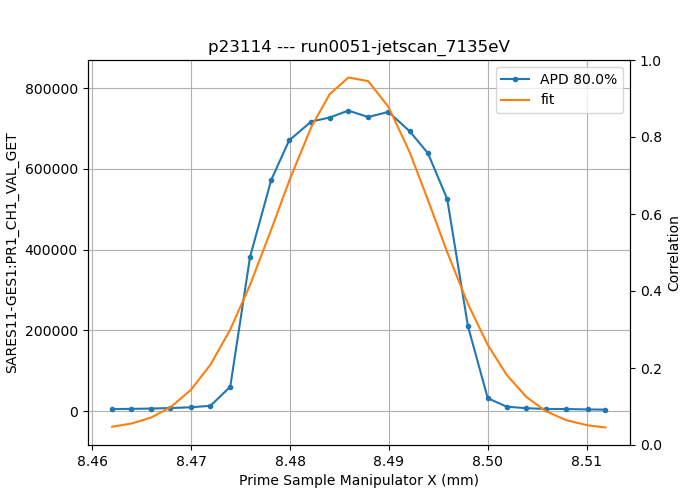

Center position = 8.487 mm
Width = 18.719 um


In [24]:
Int_APD1 = Signal_APD1[:,0]
err_low_APD1 = Signal_APD1[:,1]
err_high_APD1 = Signal_APD1[:,2]
correlation1 = correlation1

units = scan.parameters['units'][0]
label = scan.parameters['name'][0]

fit = Fit(gaussian, estimate_gaussian_parameters)
fit.estimate(Position_mm, Int_APD1)            # this sets some internal params 
#fit.p0 = better_p0(fit.p0, 0, 210.42) # overwrite some values (index) if needed: 
fit.fit(Position_mm, Int_APD1)                  # calculate the fit
Int_fit = fit.eval(Position_mm)            # evaluate the curve for plotting
center = fit.popt[0]
width = fit.popt[2]*2.355

fig = plt.figure(figsize = (7,5))
ax1 = fig.add_subplot(111)
ax2 = plt.twinx(ax1)
#ax2._get_lines.prop_cycler = ax1._get_lines.prop_cycler
plt.title(titlestring)

lns1 = ax1.plot(Position_mm, Int_APD1, label='APD {}%'.format(quantile_corr*100),marker='.')
lns2 = ax1.plot(Position_mm, Int_fit, label = 'fit')
#lns3 = ax2.plot(Position_mm, correlation1, label='correlation')
#ax1.fill_between(Position_mm, err_low_APD1, err_high_APD1, color='lightblue')

ax1.set_xlabel("{} ({})".format(label, units))
ax1.set_ylabel(detector_XAS_1)
ax2.set_ylabel("Correlation")

leg = lns1 + lns2 #+ lns3
labels = [l.get_label() for l in leg]
ax1.legend(leg, labels, loc='best')

ax1.grid()
plt.show()

print("Center position = {:.3f} mm".format(center))
print("Width = {:.3f} um".format(width*1000))
#print("Bandwidth = {} %".format(np.abs(np.round(width,3))/np.round(center,3)*100))

## Plot 2 diodes

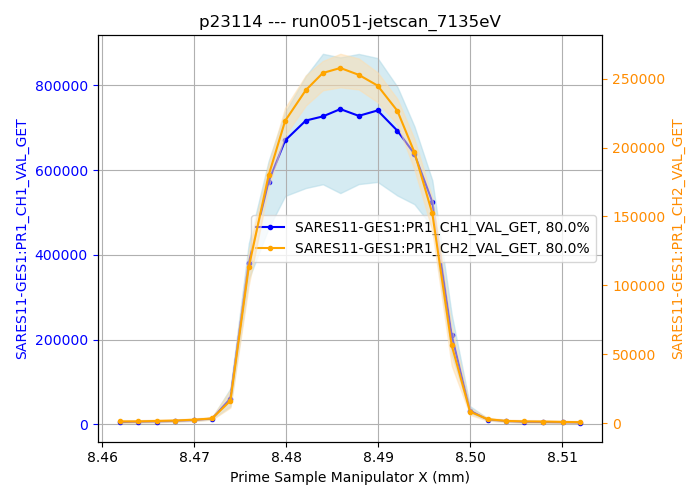

In [25]:
Int_APD1 = Signal_APD1[:,0]
err_low_APD1 = Signal_APD1[:,1]
err_high_APD1 = Signal_APD1[:,2]

Int_APD2 = Signal_APD2[:,0]
err_low_APD2 = Signal_APD2[:,1]
err_high_APD2 = Signal_APD2[:,2]

###########################################

fit = Fit(gaussian, estimate_gaussian_parameters)

fit.estimate(Position_mm, Int_APD1)            # this sets some internal params 
#fit.p0 = better_p0(fit.p0, 0, 210.42) # overwrite some values (index) if needed: 
fit.fit(Position_mm, Int_APD1)                  # calculate the fit
Int_fit1 = fit.eval(Position_mm)            # evaluate the curve for plotting
center1 = fit.popt[0]
width1 = fit.popt[2]*2.355

fit.estimate(Position_mm, Int_APD2)            # this sets some internal params 
#fit.p0 = better_p0(fit.p0, 0, 210.42) # overwrite some values (index) if needed: 
fit.fit(Position_mm, Int_APD2)                  # calculate the fit
Int_fit2 = fit.eval(Position_mm)            # evaluate the curve for plotting
center2 = fit.popt[0]
width2 = fit.popt[2]*2.355

###########################################

fig = plt.figure(figsize = (7,5))

ax1 = fig.add_subplot(111)
ax2 = plt.twinx(ax1)

#ax2._get_lines.prop_cycler = ax1._get_lines.prop_cycler

lns1 = ax1.plot(Position_mm, Int_APD1, label=detector_XAS_1+', {}%'.format(quantile_corr*100),marker='.', color='b')
ax1.fill_between(Position_mm, err_low_APD1, err_high_APD1, color='lightblue', alpha = 0.5)
#ax1.plot(Position_mm, Int_fit1, color='navy')

lns2 = ax2.plot(Position_mm, Int_APD2, label=detector_XAS_2+', {}%'.format(quantile_corr*100),marker='.', color='orange')
ax2.fill_between(Position_mm, err_low_APD2, err_high_APD2, color='navajowhite', alpha = 0.5)
#ax2.plot(Position_mm, Int_fit2, color='coral')


plt.title(titlestring)

ax1.set_xlabel("{} ({})".format(label, units))

#ax1.set_ylabel ("Normalized intensity diode1")
ax1.set_ylabel(detector_XAS_1)
ax1.tick_params(axis='y', colors='b')
ax1.yaxis.label.set_color('b')

#ax2.set_ylabel ("Normalized intensity diode2")
ax2.set_ylabel(detector_XAS_2)
ax2.tick_params(axis='y', colors='darkorange')
ax2.yaxis.label.set_color('darkorange')


leg = lns1 + lns2
labels = [l.get_label() for l in leg]
ax1.legend(leg, labels, loc='best')
#ax1.axvline(6.615)
ax1.grid()
plt.tight_layout()
plt.show()